# YouTube Trailer Engagement & Box Office Performance
**Research Question:** How are YouTube trailer engagement metrics associated with box office performance?

**Import Libraries**

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns

**Load Data**

In [115]:
yt_url  = "https://raw.githubusercontent.com/zainab05m/OMIS3020Group6/refs/heads/main/movies_youtube_sentiments.csv"
box_url = "https://raw.githubusercontent.com/zainab05m/OMIS3020Group6/refs/heads/main/enhanced_box_office_data(2000-2024)u.csv"

yt  = pd.read_csv(yt_url)
box = pd.read_csv(box_url)

**Inspect Raw Data**

In [116]:
print("YouTube dataset shape:", yt.shape)
yt.head()

YouTube dataset shape: (1105, 18)


,name,trailer_link,video_id,sentiment_scores,favorability,rating,genre,year,released,votes,director,writer,star,country,budget,gross,company,runtime
0,Harry Potter and the Goblet of Fire,https://www.youtube.com/watch?v=3EGojp4Hh6I,3EGojp4Hh6I,"{'positive': 87, 'neutral': 112, 'negative': 51}",0.630435,PG-13,Adventure,2005,"November 18, 2005 (United States)",566000.0,Mike Newell,Steve Kloves,Daniel Radcliffe,United Kingdom,150000000.0,896678241.0,Warner Bros.,157.0
1,The 40-Year-Old Virgin,https://www.youtube.com/watch?v=YnDeJn-BX5Q,YnDeJn-BX5Q,"{'positive': 40, 'neutral': 45, 'negative': 18}",0.689655,R,Comedy,2005,"August 19, 2005 (United States)",407000.0,Judd Apatow,Judd Apatow,Steve Carell,United States,26000000.0,177378645.0,Universal Pictures,116.0
2,Memoirs of a Geisha,https://www.youtube.com/watch?v=4L-xlmakQvc,4L-xlmakQvc,"{'positive': 120, 'neutral': 89, 'negative': 41}",0.745342,PG-13,Drama,2005,"December 23, 2005 (United States)",141000.0,Rob Marshall,Robin Swicord,Ziyi Zhang,France,85000000.0,162242962.0,Columbia Pictures,145.0
3,Pride & Prejudice,https://www.youtube.com/watch?v=Ur_DIHs92NM,Ur_DIHs92NM,"{'positive': 93, 'neutral': 98, 'negative': 19}",0.830357,PG,Drama,2005,"November 23, 2005 (United States)",269000.0,Joe Wright,Deborah Moggach,Keira Knightley,France,28000000.0,121616555.0,Focus Features,129.0
4,Batman Begins,https://www.youtube.com/watch?v=neY2xVmOfUM,neY2xVmOfUM,"{'positive': 128, 'neutral': 97, 'negative': 25}",0.836601,PG-13,Action,2005,"June 15, 2005 (United States)",1300000.0,Christopher Nolan,Bob Kane,Christian Bale,United Kingdom,150000000.0,373661946.0,Warner Bros.,140.0


In [117]:
print("Box office dataset shape:", box.shape)
box.head()

Box office dataset shape: (5000, 13)


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [118]:
yt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1105 entries, 0 to 1104
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1105 non-null   object 
 1   trailer_link      1105 non-null   object 
 2   video_id          1105 non-null   object 
 3   sentiment_scores  1105 non-null   object 
 4   favorability      1105 non-null   float64
 5   rating            1104 non-null   object 
 6   genre             1105 non-null   object 
 7   year              1105 non-null   int64  
 8   released          1105 non-null   object 
 9   votes             1105 non-null   float64
 10  director          1105 non-null   object 
 11  writer            1104 non-null   object 
 12  star              1105 non-null   object 
 13  country           1105 non-null   object 
 14  budget            901 non-null    float64
 15  gross             1105 non-null   float64
 16  company           1105 non-null   object 


In [119]:
box.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  5000 non-null   int64  
 1   Release Group         5000 non-null   object 
 2   $Worldwide            5000 non-null   float64
 3   $Domestic             5000 non-null   float64
 4   Domestic %            5000 non-null   float64
 5   $Foreign              5000 non-null   float64
 6   Foreign %             5000 non-null   float64
 7   Year                  5000 non-null   int64  
 8   Genres                4822 non-null   object 
 9   Rating                4830 non-null   object 
 10  Vote_Count            4830 non-null   float64
 11  Original_Language     4830 non-null   object 
 12  Production_Countries  4800 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 507.9+ KB


In [120]:
yt.describe()

,favorability,year,votes,budget,gross,runtime
count,1105.000000,1105.000000,1.105000e+03,9.010000e+02,1.105000e+03,1104.000000
mean,0.679717,2010.043439,1.364592e+05,4.306125e+07,1.060908e+08,109.175725
std,0.132921,6.095252,1.728636e+05,4.692794e+07,1.698105e+08,16.974139
min,0.000000,1980.000000,3.360000e+02,1.500000e+04,1.808000e+03,75.000000
25%,0.610390,2007.000000,3.400000e+04,1.200000e+07,1.060642e+07,96.750000
50%,0.689655,2010.000000,7.300000e+04,2.800000e+07,4.473466e+07,106.000000
75%,0.760000,2014.000000,1.670000e+05,5.500000e+07,1.258562e+08,118.000000
max,1.000000,2019.000000,1.600000e+06,3.000000e+08,1.236005e+09,193.000000


In [121]:
box.describe()

,Rank,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Vote_Count
count,5000.00000,5.000000e+03,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,4830.000000
mean,100.50000,1.192137e+08,4.472523e+07,35.740620,7.448809e+07,64.256640,2012.000000,2531.585921
std,57.74008,2.005243e+08,7.727026e+07,30.656992,1.334932e+08,30.654531,7.211824,3946.272827
min,1.00000,1.666028e+06,0.000000e+00,0.000000,0.000000e+00,0.000000,2000.000000,0.000000
25%,50.75000,2.466220e+07,9.275150e+04,0.200000,1.371034e+07,42.200000,2006.000000,205.250000
50%,100.50000,4.844658e+07,1.798421e+07,37.050000,3.019444e+07,62.950000,2012.000000,1035.500000
75%,150.25000,1.197588e+08,5.386847e+07,57.800000,7.211578e+07,99.800000,2018.000000,3065.000000
max,200.00000,2.799439e+09,9.366622e+08,100.000000,1.993811e+09,100.000000,2024.000000,36753.000000


**Check for Missing Values**

In [122]:
print("Missing values — YouTube:")
print(yt.isnull().sum())

Missing values — YouTube:
name                  0
trailer_link          0
video_id              0
sentiment_scores      0
favorability          0
rating                1
genre                 0
year                  0
released              0
votes                 0
director              0
writer                1
star                  0
country               0
budget              204
gross                 0
company               0
runtime               1
dtype: int64


In [123]:
print("Missing values - Box office:")
print(box.isnull().sum())

Missing values — Box office:
Rank                      0
Release Group             0
$Worldwide                0
$Domestic                 0
Domestic %                0
$Foreign                  0
Foreign %                 0
Year                      0
Genres                  178
Rating                  170
Vote_Count              170
Original_Language       170
Production_Countries    200
dtype: int64


**Rename Columns**

In [124]:
yt = yt.rename(columns={
    'name':             'movie_title',
    'year':             'release_year',
    'favorability':     'youtube_favorability',
    'sentiment_scores': 'youtube_sentiment_scores'
})

box = box.rename(columns={
    'Release Group': 'movie_title',
    'Year':          'release_year',
    '$Worldwide':    'worldwide_revenue'
})

**Clean**

In [125]:
#Keep only what we need from box office (target variable only)
box_slim = box[['movie_title', 'release_year', 'worldwide_revenue']].copy()
box_slim = box_slim.dropna()

#Keep YouTube engagement columns + controls
yt_keep = yt[[
    'movie_title',
    'release_year',
    'youtube_favorability',
    'youtube_sentiment_scores',
    'budget',
    'runtime',
    'votes',
    'genre'
]].copy()
yt_keep = yt_keep.dropna()

print("Box office (slim) shape:", box_slim.shape)
print("YouTube (slim) shape:", yt_keep.shape)

Box office (slim) shape: (5000, 3)
YouTube (slim) shape: (900, 8)


**Merge Datasets**

In [126]:
df = pd.merge(
    yt_keep,
    box_slim,
    on=['movie_title', 'release_year'],
    how='inner'
)

print("Merged shape:", df.shape)
df.head()

Merged shape: (626, 9)


,movie_title,release_year,youtube_favorability,youtube_sentiment_scores,budget,runtime,votes,genre,worldwide_revenue
0,Harry Potter and the Goblet of Fire,2005,0.630435,"{'positive': 87, 'neutral': 112, 'negative': 51}",150000000.0,157.0,566000.0,Adventure,895921036.0
1,The 40-Year-Old Virgin,2005,0.689655,"{'positive': 40, 'neutral': 45, 'negative': 18}",26000000.0,116.0,407000.0,Comedy,177378645.0
2,Memoirs of a Geisha,2005,0.745342,"{'positive': 120, 'neutral': 89, 'negative': 41}",85000000.0,145.0,141000.0,Drama,162242962.0
3,Pride & Prejudice,2005,0.830357,"{'positive': 93, 'neutral': 98, 'negative': 19}",28000000.0,129.0,269000.0,Drama,121616555.0
4,Batman Begins,2005,0.836601,"{'positive': 128, 'neutral': 97, 'negative': 25}",150000000.0,140.0,1300000.0,Action,373443774.0


**Inspect Merged Dataset**

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   movie_title               626 non-null    object 
 1   release_year              626 non-null    int64  
 2   youtube_favorability      626 non-null    float64
 3   youtube_sentiment_scores  626 non-null    object 
 4   budget                    626 non-null    float64
 5   runtime                   626 non-null    float64
 6   votes                     626 non-null    float64
 7   genre                     626 non-null    object 
 8   worldwide_revenue         626 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 44.1+ KB


In [128]:
df.describe()

,release_year,youtube_favorability,budget,runtime,votes,worldwide_revenue
count,626.000000,626.000000,6.260000e+02,626.000000,6.260000e+02,6.260000e+02
mean,2010.365815,0.685090,5.419225e+07,111.789137,1.940212e+05,1.692221e+08
std,4.245888,0.123255,5.032679e+07,17.586457,1.947051e+05,1.975303e+08
min,2005.000000,0.000000,1.000000e+05,75.000000,7.300000e+03,1.418986e+07
25%,2007.000000,0.622367,2.000000e+07,99.000000,6.725000e+04,4.945316e+07
50%,2009.000000,0.697076,3.500000e+07,109.000000,1.225000e+05,9.774496e+07
75%,2014.000000,0.762962,7.000000e+07,122.000000,2.497500e+05,1.945153e+08
max,2018.000000,1.000000,3.000000e+08,187.000000,1.600000e+06,1.236005e+09


In [129]:
print("Missing values after merge:")
print(df.isnull().sum())

Missing values after merge:
movie_title                 0
release_year                0
youtube_favorability        0
youtube_sentiment_scores    0
budget                      0
runtime                     0
votes                       0
genre                       0
worldwide_revenue           0
dtype: int64


In [130]:
print("Duplicates before:", df.duplicated(subset=['movie_title', 'release_year']).sum())
df = df.drop_duplicates(subset=['movie_title', 'release_year'], keep='first')
print("Shape after removing duplicates:", df.shape)


Duplicates before: 2
Shape after removing duplicates: (624, 9)


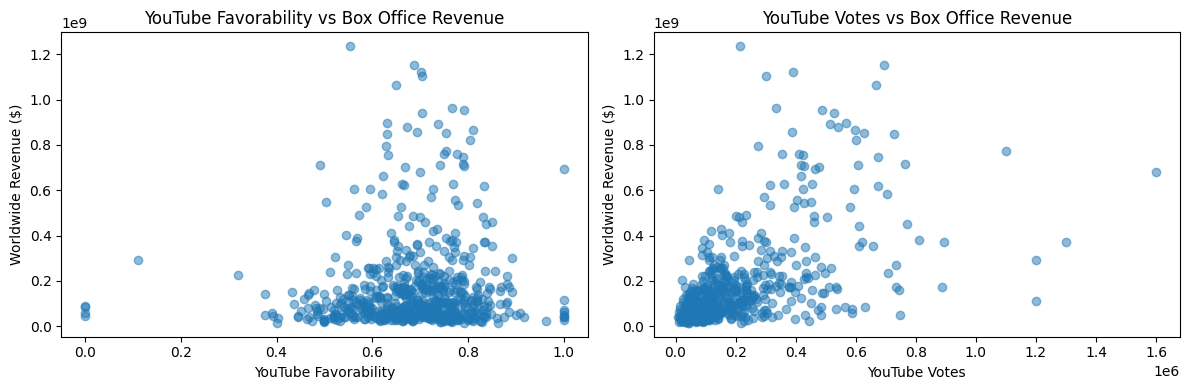

In [131]:
#EDA

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['youtube_favorability'], df['worldwide_revenue'], alpha=0.5)
axes[0].set_xlabel('YouTube Favorability')
axes[0].set_ylabel('Worldwide Revenue ($)')
axes[0].set_title('YouTube Favorability vs Box Office Revenue')

axes[1].scatter(df['votes'], df['worldwide_revenue'], alpha=0.5)
axes[1].set_xlabel('YouTube Votes')
axes[1].set_ylabel('Worldwide Revenue ($)')
axes[1].set_title('YouTube Votes vs Box Office Revenue')

plt.tight_layout()
plt.show()


<Figure size 1200x500 with 0 Axes>

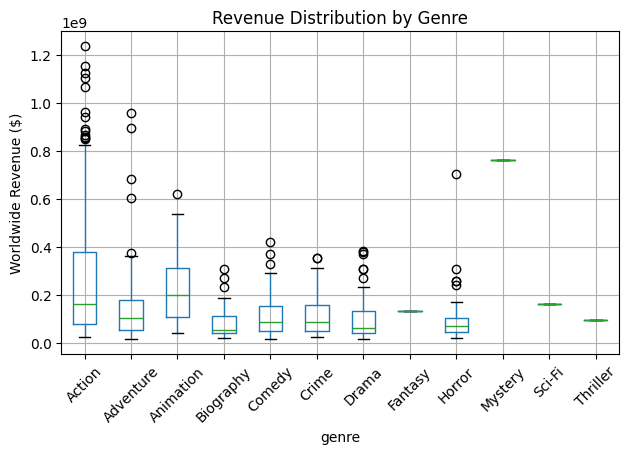

In [132]:
#EDA

plt.figure(figsize=(12, 5))
df.boxplot(column='worldwide_revenue', by='genre', rot=45)
plt.title('Revenue Distribution by Genre')
plt.suptitle('')
plt.ylabel('Worldwide Revenue ($)')
plt.tight_layout()
plt.show()


**Feature Engineering**

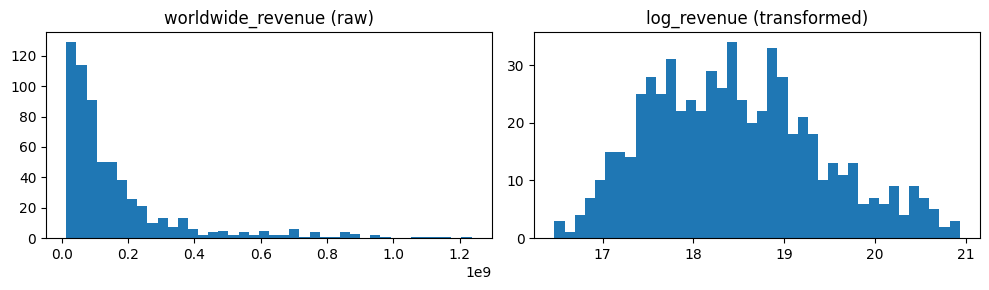

In [133]:
#Log-transform skewed numeric columns
df['log_revenue'] = np.log1p(df['worldwide_revenue'])
df['log_budget']  = np.log1p(df['budget'])

#visualizations
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(df['worldwide_revenue'], bins=40)
axes[0].set_title("worldwide_revenue (raw)")
axes[1].hist(df['log_revenue'], bins=40)
axes[1].set_title("log_revenue (transformed)")
plt.tight_layout()
plt.show()

In [134]:
#Split sentiment into separate numeric columns

sent = df['youtube_sentiment_scores'].apply(eval).apply(pd.Series)

sent = sent.rename(columns={
    'positive': 'sent_positive',
    'neutral':  'sent_neutral',
    'negative': 'sent_negative'
})
df = pd.concat([df, sent], axis=1)

#drop neutral to avoid multicollinearity
sent_total = df[['sent_positive', 'sent_neutral', 'sent_negative']].sum(axis=1)
df['sent_positive_pct'] = df['sent_positive'] / sent_total
df['sent_negative_pct'] = df['sent_negative'] / sent_total

df = df.dropna(subset=['sent_positive_pct', 'sent_negative_pct'])
print("Shape after sentiment parsing:", df.shape)

Shape after sentiment parsing: (624, 16)


In [135]:
df[['movie_title', 'sent_positive', 'sent_neutral', 'sent_negative', 'sent_positive_pct', 'sent_negative_pct']].head()


,movie_title,sent_positive,sent_neutral,sent_negative,sent_positive_pct,sent_negative_pct
0,Harry Potter and the Goblet of Fire,87,112,51,0.348000,0.204000
1,The 40-Year-Old Virgin,40,45,18,0.388350,0.174757
2,Memoirs of a Geisha,120,89,41,0.480000,0.164000
3,Pride & Prejudice,93,98,19,0.442857,0.090476
4,Batman Begins,128,97,25,0.512000,0.100000


In [136]:
#one hot encode genre
df = pd.get_dummies(df, columns=['genre'], drop_first=True)

genre_cols = [col for col in df.columns if col.startswith('genre_')]
print("Genre columns:", genre_cols)

Genre columns: ['genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama', 'genre_Fantasy', 'genre_Horror', 'genre_Mystery', 'genre_Sci-Fi', 'genre_Thriller']


In [137]:
df.head()

,movie_title,release_year,youtube_favorability,youtube_sentiment_scores,budget,runtime,votes,worldwide_revenue,log_revenue,log_budget,...,genre_Animation,genre_Biography,genre_Comedy,genre_Crime,genre_Drama,genre_Fantasy,genre_Horror,genre_Mystery,genre_Sci-Fi,genre_Thriller
0,Harry Potter and the Goblet of Fire,2005,0.630435,"{'positive': 87, 'neutral': 112, 'negative': 51}",150000000.0,157.0,566000.0,895921036.0,20.613363,18.826146,...,False,False,False,False,False,False,False,False,False,False
1,The 40-Year-Old Virgin,2005,0.689655,"{'positive': 40, 'neutral': 45, 'negative': 18}",26000000.0,116.0,407000.0,177378645.0,18.993797,17.073607,...,False,False,True,False,False,False,False,False,False,False
2,Memoirs of a Geisha,2005,0.745342,"{'positive': 120, 'neutral': 89, 'negative': 41}",85000000.0,145.0,141000.0,162242962.0,18.904606,18.258162,...,False,False,False,False,True,False,False,False,False,False
3,Pride & Prejudice,2005,0.830357,"{'positive': 93, 'neutral': 98, 'negative': 19}",28000000.0,129.0,269000.0,121616555.0,18.616384,17.147715,...,False,False,False,False,True,False,False,False,False,False
4,Batman Begins,2005,0.836601,"{'positive': 128, 'neutral': 97, 'negative': 25}",150000000.0,140.0,1300000.0,373443774.0,19.738278,18.826146,...,False,False,False,False,False,False,False,False,False,False


**Define Features and Target**

In [138]:
#Split features into YouTube metrics and controls

YOUTUBE_FEATURES = ['youtube_favorability', 'sent_positive_pct', 'sent_negative_pct', 'votes']
genre_cols = [col for col in df.columns if col.startswith('genre_')]
CONTROL_FEATURES = ['log_budget', 'runtime'] + genre_cols
ALL_FEATURES     = YOUTUBE_FEATURES + CONTROL_FEATURES
TARGET           = 'log_revenue'

print("YouTube features:", YOUTUBE_FEATURES)
print("Control features:", CONTROL_FEATURES)

model_df = df[ALL_FEATURES + [TARGET]].dropna()
print("\nRows available for modelling:", len(model_df))


YouTube features: ['youtube_favorability', 'sent_positive_pct', 'sent_negative_pct', 'votes']
Control features: ['log_budget', 'runtime', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Drama', 'genre_Fantasy', 'genre_Horror', 'genre_Mystery', 'genre_Sci-Fi', 'genre_Thriller']

Rows available for modelling: 624


**Train/Test Split**

In [139]:
#80/20 split

X = model_df[ALL_FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (499, 17) Test: (125, 17)


**Baseline Linear Regression**

In [140]:
#Baseline model uses only YouTube features to see how much trailer engagement alone explains

lr_baseline = LinearRegression()
lr_baseline.fit(X_train[YOUTUBE_FEATURES], y_train)
y_pred_base = lr_baseline.predict(X_test[YOUTUBE_FEATURES])

print("Baseline LR (YouTube features only)")
print("R²:", round(r2_score(y_test, y_pred_base), 4))
mae_dollars_base = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_base))
print("MAE:$" + f"{mae_dollars_base:,.0f}")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_base)), 4))

Baseline LR (YouTube features only)
R²: 0.3324
MAE:$81,530,126
RMSE: 0.7224


 **Full Linear Regression**

In [141]:
#Full model adds budget, runtime, and genre as controls to isolate YouTube's true contribution

lr_full = LinearRegression()
lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_test)

print("Full LR (YouTube + controls)")
print("R²:", round(r2_score(y_test, y_pred_full), 4))
mae_dollars_full = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_full))
print("MAE:$" + f"{mae_dollars_full:,.0f}")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_full)), 4))

Full LR (YouTube + controls)
R²: 0.526
MAE:$69,090,603
RMSE: 0.6087


**Standardized Coefficients**

In [142]:
#Scale features to the same range

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_std = LinearRegression()
lr_std.fit(X_train_scaled, y_train)

#Label each feature as YouTube or Control
feature_types = ['YouTube']*len(YOUTUBE_FEATURES) + ['Control']*len(CONTROL_FEATURES)

coeff_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Std_Coeff': lr_std.coef_,
    'Type': feature_types
}).sort_values('Std_Coeff', ascending=False)

print(coeff_df.head(10).to_string(index=False))


             Feature  Std_Coeff    Type
          log_budget   0.417996 Control
               votes   0.410850 YouTube
youtube_favorability   0.085687 YouTube
             runtime   0.062572 Control
     genre_Animation   0.059591 Control
        genre_Horror   0.046931 Control
       genre_Mystery   0.033943 Control
   sent_negative_pct   0.019507 YouTube
       genre_Fantasy   0.007832 Control
      genre_Thriller   0.000000 Control


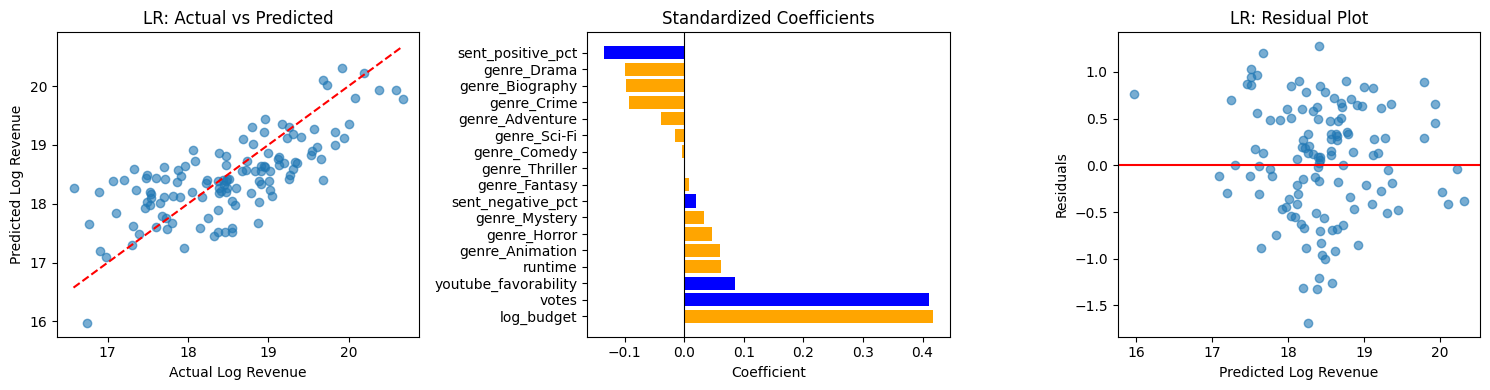

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Actual vs Predicted
axes[0].scatter(y_test, y_pred_full, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual Log Revenue")
axes[0].set_ylabel("Predicted Log Revenue")
axes[0].set_title("LR: Actual vs Predicted")

#Standardized coefficients
colors = ['blue' if t == 'YouTube' else 'orange' for t in coeff_df['Type']]
axes[1].barh(coeff_df['Feature'], coeff_df['Std_Coeff'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Standardized Coefficients")
axes[1].set_xlabel("Coefficient")

#Residual plot
residuals = y_test - y_pred_full
axes[2].scatter(y_pred_full, residuals, alpha=0.6)
axes[2].axhline(0, color='red')
axes[2].set_xlabel("Predicted Log Revenue")
axes[2].set_ylabel("Residuals")
axes[2].set_title("LR: Residual Plot")

plt.tight_layout()
plt.show()

**Random Forest**

In [144]:
#random forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest:")
print("R²:", round(r2_score(y_test, y_pred_rf), 4))
mae_dollars_rf = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))
print("MAE:$" + f"{mae_dollars_rf:,.0f}")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4))

Random Forest:
R²: 0.573
MAE:$62,551,849
RMSE: 0.5777


In [145]:
#rank Random Forest features
feature_types = ['YouTube']*len(YOUTUBE_FEATURES) + ['Control']*len(CONTROL_FEATURES)

importance_df = pd.DataFrame({
    'Feature':    ALL_FEATURES,
    'Importance': rf_model.feature_importances_,
    'Type':       feature_types
}).sort_values('Importance', ascending=False)

print("Feature Importances (Top 10):")
print(importance_df.head(10).to_string(index=False))


Feature Importances (Top 10):
             Feature  Importance    Type
          log_budget    0.381284 Control
               votes    0.290824 YouTube
             runtime    0.094794 Control
   sent_positive_pct    0.066224 YouTube
   sent_negative_pct    0.059161 YouTube
youtube_favorability    0.055426 YouTube
         genre_Drama    0.016410 Control
     genre_Biography    0.009450 Control
        genre_Comedy    0.009114 Control
         genre_Crime    0.005718 Control


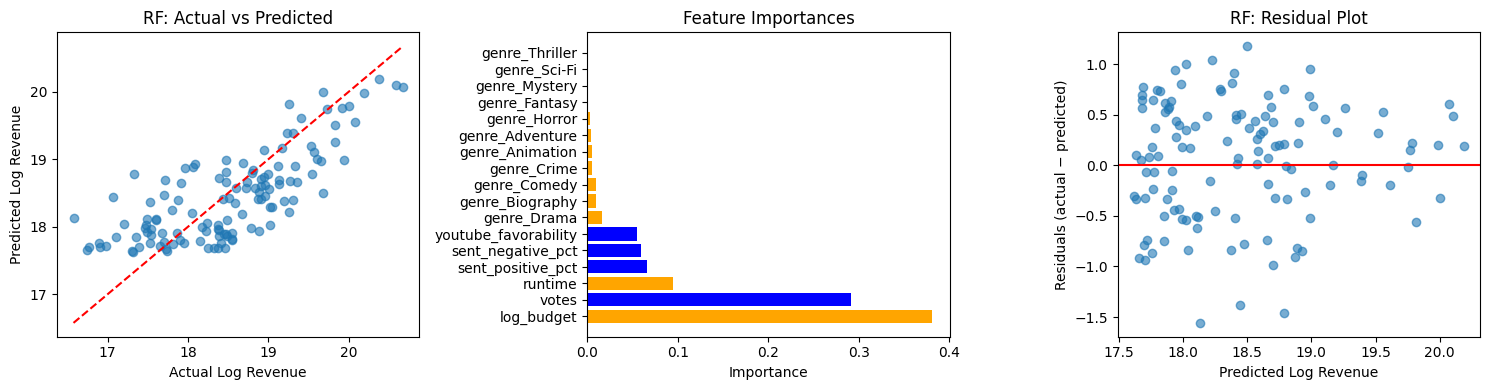

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Actual vs predicted

axes[0].scatter(y_test, y_pred_rf, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual Log Revenue")
axes[0].set_ylabel("Predicted Log Revenue")
axes[0].set_title("RF: Actual vs Predicted")

#Feature importance

colors_imp = ['blue' if t == 'YouTube' else 'orange' for t in importance_df['Type']]
axes[1].barh(importance_df['Feature'], importance_df['Importance'], color=colors_imp)
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance")

#Residual plot
residuals_rf = y_test - y_pred_rf
axes[2].scatter(y_pred_rf, residuals_rf, alpha=0.6)
axes[2].axhline(0, color='red')
axes[2].set_xlabel("Predicted Log Revenue")
axes[2].set_ylabel("Residuals (actual − predicted)")
axes[2].set_title("RF: Residual Plot")

plt.tight_layout()
plt.show()

**Decision Tree**

In [147]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree:")
print("R²:", round(r2_score(y_test, y_pred_dt), 4))
mae_dollars_dt = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_dt))
print("MAE:$" + f"{mae_dollars_dt:,.0f}")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4))


Decision Tree:
R²: 0.4319
MAE:$70,594,505
RMSE: 0.6664


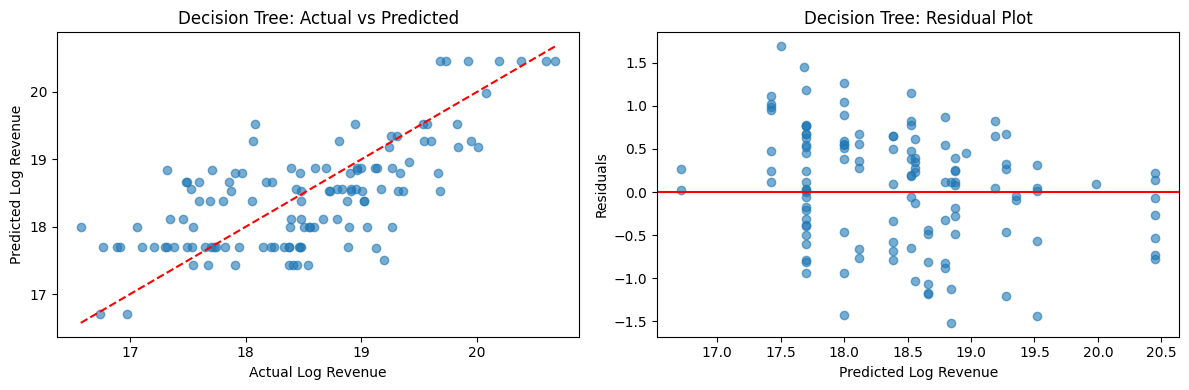

In [148]:
#Actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_dt, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual Log Revenue")
axes[0].set_ylabel("Predicted Log Revenue")
axes[0].set_title("Decision Tree: Actual vs Predicted")

#Residual plot
residuals_dt = y_test - y_pred_dt
axes[1].scatter(y_pred_dt, residuals_dt, alpha=0.6)
axes[1].axhline(0, color='red')
axes[1].set_xlabel("Predicted Log Revenue")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Decision Tree: Residual Plot")

plt.tight_layout()
plt.show()


**Correlation Matrix**

In [149]:
#Build correlation matrix using all features + target
corr_matrix = model_df[ALL_FEATURES + [TARGET]].corr().round(2)

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                      youtube_favorability  sent_positive_pct  \
youtube_favorability                  1.00               0.69   
sent_positive_pct                     0.69               1.00   
sent_negative_pct                    -0.75              -0.28   
votes                                 0.14               0.09   
log_budget                            0.06              -0.03   
runtime                               0.13               0.15   
genre_Adventure                       0.06               0.07   
genre_Animation                       0.01              -0.08   
genre_Biography                       0.02               0.03   
genre_Comedy                          0.13               0.10   
genre_Crime                           0.03               0.02   
genre_Drama                          -0.02               0.06   
genre_Fantasy                        -0.02              -0.02   
genre_Horror                         -0.31              -0.21   
genre

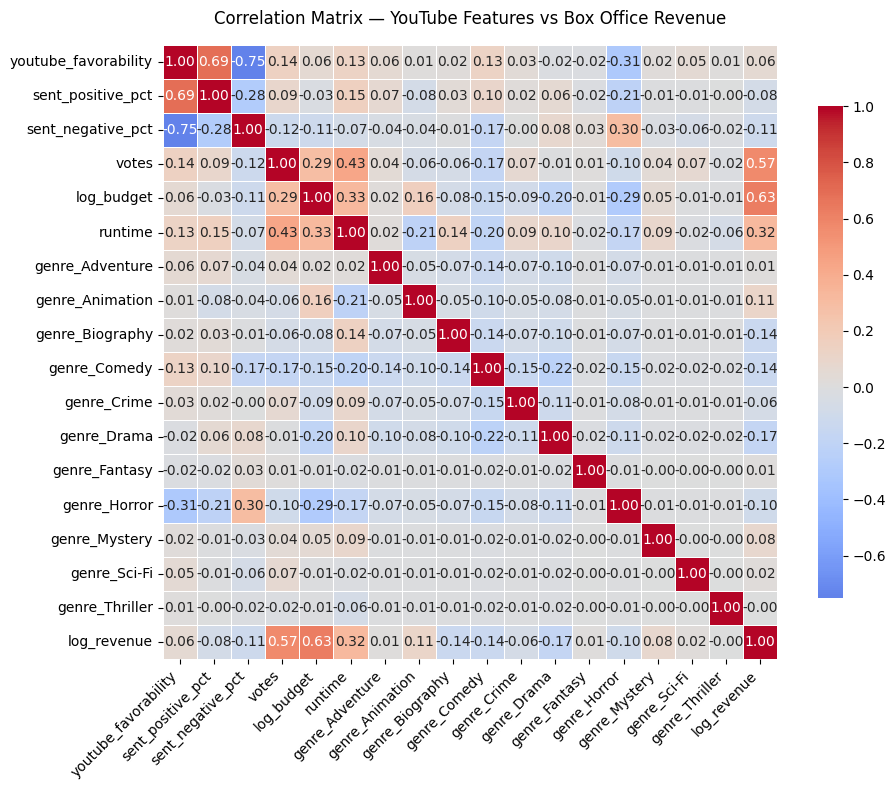

In [150]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix — YouTube Features vs Box Office Revenue", pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Model Comparison**

In [151]:
#Compare all models side by side to see which one performed best

results = pd.DataFrame({
    'Model':['Baseline LR (YouTube Only)', 'Full LR (YouTube + Controls)', 'Decision Tree', 'Random Forest'],
    'R²':[r2_score(y_test, y_pred_base), r2_score(y_test, y_pred_full), r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_rf)],
    'MAE':[mean_absolute_error(y_test, y_pred_base), mean_absolute_error(y_test, y_pred_full), mean_absolute_error(y_test, y_pred_dt), mean_absolute_error(y_test, y_pred_rf)],
    'RMSE':[np.sqrt(mean_squared_error(y_test, y_pred_base)), np.sqrt(mean_squared_error(y_test, y_pred_full)), np.sqrt(mean_squared_error(y_test, y_pred_dt)), np.sqrt(mean_squared_error(y_test, y_pred_rf))]
}).round(4)

results = results.sort_values('R²', ascending=False)
display(results)


,Model,R²,MAE,RMSE
3,Random Forest,0.5730,0.4827,0.5777
1,Full LR (YouTube + Controls),0.5260,0.5026,0.6087
2,Decision Tree,0.4319,0.5487,0.6664
0,Baseline LR (YouTube Only),0.3324,0.5755,0.7224
